# Plotting Utilities for DSP & Sonar

Standardized, reusable plots are critical for DSP debugging, interpretation, publication, and interviews.

**Why?**
- Instantly understand signal features
- Catch bugs or unexpected processing artifacts
- Show results professionally (README, interview, paper)

This notebook provides go-to plotting functions and demos for your DSP/sonar toolbox.

---


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def plot_time_series(signal, t=None, title='Time Series', xlabel='Time (s)', ylabel='Amplitude'):
    if t is None:
        t = np.arange(len(signal))
    plt.figure(figsize=(8,3))
    plt.plot(t, signal)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_frequency_spectrum(signal, fs, title='Frequency Spectrum'):
    n = len(signal)
    freq = np.fft.rfftfreq(n, d=1/fs)
    fft_mag = np.abs(np.fft.rfft(signal))
    plt.figure(figsize=(8,3))
    plt.plot(freq, fft_mag)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_array_geometry(array_pos, title='Array Geometry'):
    plt.figure(figsize=(6,2))
    plt.scatter(array_pos, np.zeros_like(array_pos), marker='o', s=80, color='navy')
    for idx, pos in enumerate(array_pos):
        plt.text(pos, 0.02, f'{idx+1}', ha='center')
    plt.title(title)
    plt.xlabel('Position (m)')
    plt.yticks([])
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

def plot_spectrogram(signal, fs, nperseg=128, noverlap=64, title='Spectrogram'):
    f, t, Sxx = spectrogram(signal, fs, nperseg=nperseg, noverlap=noverlap)
    plt.figure(figsize=(8,3))
    plt.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='gouraud')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.title(title)
    plt.colorbar(label='Power (dB)')
    plt.tight_layout()
    plt.show()


### Time Series Plot Demo

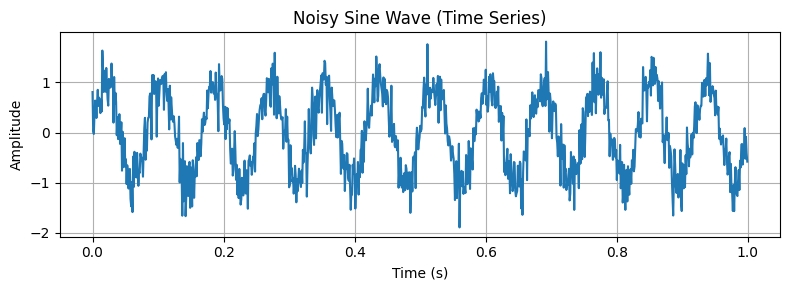

In [7]:
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
sig = np.sin(2*np.pi*12*t) + 0.3*np.random.randn(len(t))
plot_time_series(sig, t, title='Noisy Sine Wave (Time Series)')


### Frequency Spectrum Plot Demo

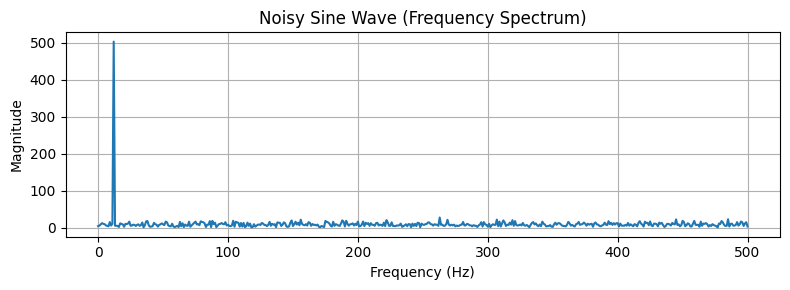

In [8]:
plot_frequency_spectrum(sig, fs, title='Noisy Sine Wave (Frequency Spectrum)')


### Array Geometry Plot Demo

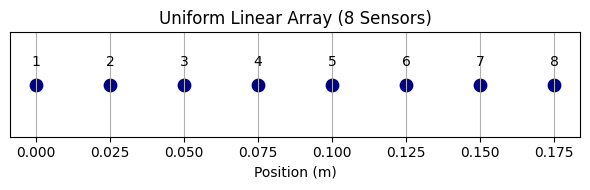

In [9]:
array_pos = np.arange(8) * 0.025  # 8 elements, 2.5cm spacing
plot_array_geometry(array_pos, title='Uniform Linear Array (8 Sensors)')


### Spectrogram Plot Demo

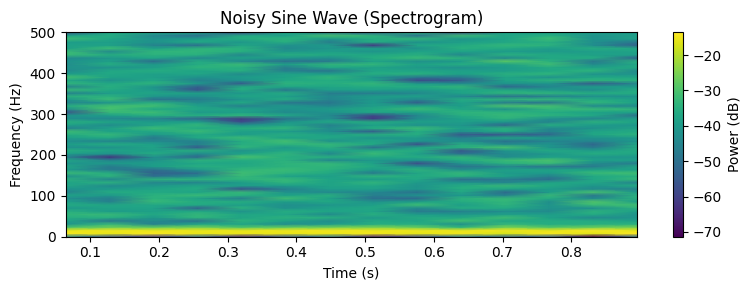

In [10]:
plot_spectrogram(sig, fs, nperseg=128, noverlap=64, title='Noisy Sine Wave (Spectrogram)')


---
## Typical Use-Cases
- Use time series for raw signals, filter outputs
- Frequency spectrum for filter performance, FFT, periodicity
- Array geometry for array processing, beamforming
- Spectrograms for non-stationary signals, echo analysis, events

**Keep these as your “boilerplate” for all DSP projects/interviews!**
